In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ep_processing import *
from utils.visualization import * 

In [2]:
my_experiment_name = "amip"
my_runid = "agm-diagn-cc-amip" # change this to "agm-amip-test" or whatever experiment you want to look at!

# Some example paths if you're running of Trillium instead...
# my_base_path = "/scratch/agmorgan/canesm_runs/{runid}/data/nc_output/CMIP6/CMIP/CP4C/CanESM5-1/{experiment_name}/r1i1p1f1/"
# my_daily_path = "day/{var_name}/gn/v20190429/{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_file_path = "{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

conv = 86400. 

# All precip
ds_pr_daily = conv * get_ds(
                    "pr",
                    my_runid, 
                    my_experiment_name,
                    year_range,
                    base_path = my_base_path,
                    file_path = my_file_path,
)

# Convective precip 
ds_prc_daily = conv * get_ds(
                    "prc",
                    my_runid, 
                    my_experiment_name,
                    year_range,
                    base_path = my_base_path,
                    file_path = my_file_path,
)

# Resolved precip 
da_prr_daily = ds_pr_daily.pr - ds_prc_daily.prc

In [3]:
# my_ areacell_path = "fx/areacella/gn/v20190429/areacella_fx_CanESM5-1_{experiment_name}_r1i1p1f1_gn.nc"
my_areacell_path = "areacella_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

ds_areacella = get_ds_areacell(
                    my_runid, 
                    my_experiment_name,
                    base_path = my_base_path,
                    areacell_path = my_areacell_path,
)
global_area = ds_areacella.areacella.sum(dim=['lon', 'lat'])         

In [4]:
def get_day_of_extreme(da, year):
    return select_fixed_year(da, year).idxmax(dim = "time")

In [5]:
da_epr_as_temporal_list = []
da_eprc_as_temporal_list = []

for year in year_range:
    day_of_epe = get_day_of_extreme(ds_pr_daily.pr, year)
    
    da_epr_current_year = ds_pr_daily.pr.sel(time = day_of_epe)
    da_eprc_current_year = ds_prc_daily.prc.sel(time = day_of_epe)
    
    da_epr_as_temporal_list.append(da_epr_current_year)
    da_eprc_as_temporal_list.append(da_eprc_current_year)

In [6]:
def to_yearly_dataarray(da, da_processed, year_range):
    return xr.DataArray(
            data = da_processed,
            dims = ["time", "lat", "lon"],
            coords = dict(
                lon = da.lon.to_numpy(),
                lat = da.lat.to_numpy(),
                time = [year for year in year_range],
            ),
    )

In [7]:
da_epr = to_yearly_dataarray(ds_pr_daily.pr, da_epr_as_temporal_list, year_range)
da_eprc = to_yearly_dataarray(ds_prc_daily.prc, da_eprc_as_temporal_list, year_range)
da_eprr = da_epr - da_eprc

In [8]:
da_epr_mean = da_epr.mean(dim = "time")
da_eprc_mean = da_eprc.mean(dim = "time")
da_eprr_mean = da_eprr.mean(dim = "time")

da_epr_max = da_epr_mean.max().values

Let's make some maps to determine whether precipitaton partitioning occurs. 

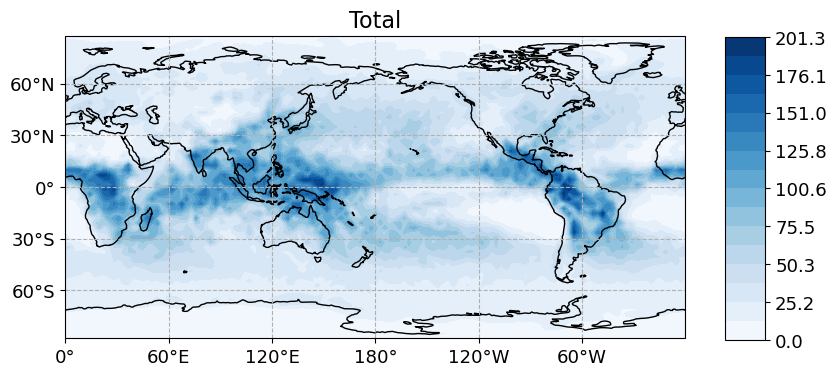

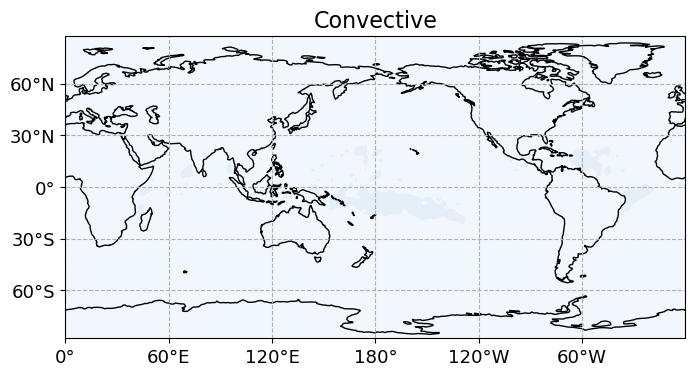

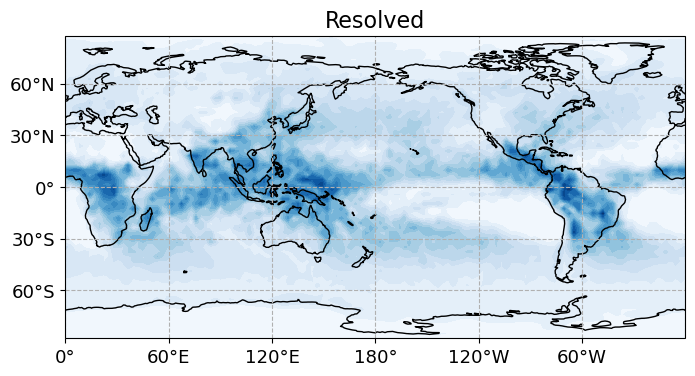

In [9]:
da_list = [da_epr_mean, da_eprc_mean, da_eprr_mean]
label_list = ["Total", "Convective", "Resolved"]

for da, label in zip(da_list, label_list):

    field_vals, lon_plt, lat_plt = process_for_map(da)
    draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = label,
        filled = True,
        show_fig = False,
        save_fig = True,
        levels = 16,
        cmap = "Blues",
        cbar_params = [0.95, 0.24, 0.05, 0.505], # position, upper offset, width, cbar length
        vmin = 0,
        vmax = da_epr_max,
        draw_labels = False,
        label_contours = False,
        remove_cbar = True if label != "Total" else False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = "amip_diagn_cc_experiment2" + label + ".png",
    )

Next, to quantify these maps, we get a rough sketch of the fraction of resolved precipitation during tropical EPEs.

In [10]:
def get_resolved_ep_fraction_in_tropics(
        # da_pr,
        # da_prr,
        da_epr,
        da_eprr,
        ds_areacell,
        tropical_halfwidth = 23.4,
):
    """
    Get the fraction of convective precipitation in the tropics
    """
    conv = MM_PER_H_TO_MM_PER_D_CONVERSION_FACTOR

    # climatology_das = [
    #     da.mean(dim = "time") for da in [da_pr, da_prr]
    # ]

    extreme_das = [
        da_epr.where(da_epr > 0),
        da_eprr.where(da_epr > 0),
    ]

    # anomaly_das = [
    #     extreme - climatology for extreme, climatology in zip(extreme_das, climatology_das)
    # ]

    da_fraction = (extreme_das[-1] / extreme_das[0]).mean(dim = "time")

    # Now get the spatial mean
    da_fraction_spatial_mean = get_tropical_areamean(
        da_fraction,
        ds_areacell,
        tropical_halfwidth = tropical_halfwidth
    )
    return da_fraction, da_fraction_spatial_mean

In [11]:
tropical_halfwidth = 40.

In [12]:
da_resolved_fraction, da_resolved_fraction_spatial_mean = get_resolved_ep_fraction_in_tropics(
        #ds_pr_daily.pr,
        #da_prr_daily,
        da_epr,
        da_eprr,
        ds_areacella,
        tropical_halfwidth = tropical_halfwidth,
)

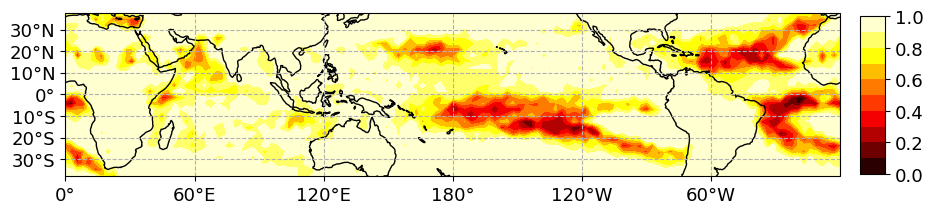

Area-weighted spatial mean of resolved fraction = 0.8575066924095154


In [13]:
field_vals, lon_plt, lat_plt = process_for_map(da_resolved_fraction)
draw_global_map(
        lon_plt,
        lat_plt,
        field_vals,
        title = None,
        filled = True,
        show_fig = True,
        save_fig = True,
        levels = 10,
        bbox = [0, 360, -tropical_halfwidth + 2, tropical_halfwidth - 2],
        cmap = "hot",
        cbar_params = [0.92, 0.23, 0.025, 0.525], # position, upper offset, width, cbar length
        xtickdelta = 60,
        ytickdelta = 10,
        figsize = (10, 3),
        vmin = 0,
        vmax = 1.0,
        draw_labels = False,
        label_contours = False,
        remove_cbar = False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        outfilename = "amip_diagn_cc_resolved_fraction_experiment2" + ".png",
)

print(f"Area-weighted spatial mean of resolved fraction = {da_resolved_fraction_spatial_mean}")

Check mean precipitation time series against benchmarks available on the [RTD browser](http://206.12.97.61:8500/). 

np.float32(247269.8)

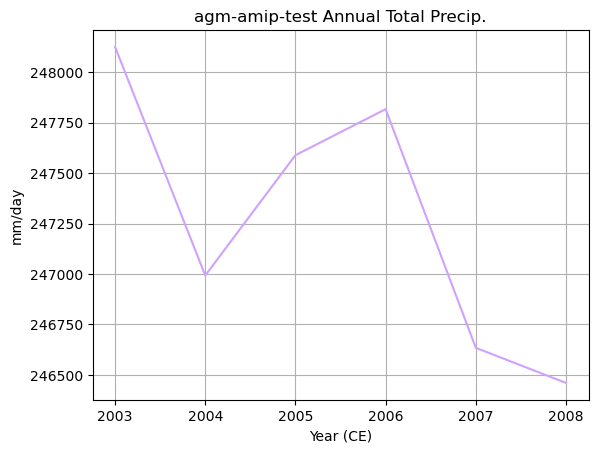

In [14]:
pr_gm = (ds_areacella.areacella * ds_pr_daily.pr).sum(dim=['lon', 'lat']) / global_area # Properly area weighted mean of rate of flux
time_scale = 60*60*24 # Number of seconds in a day 
(time_scale*pr_gm.groupby('time.year').mean(dim='time')).plot(color="xkcd:lilac")
plt.grid()
plt.title("agm-amip-test Annual Total Precip.")
plt.xlabel("Year (CE)")
plt.ylabel("mm/day")
pr_mean = time_scale*pr_gm.mean(dim='time').values
pr_mean